# TabDDPM: Hospital Readmission Prediction
## Stage 1 — Data Preprocessing

**Goal:** Convert the raw `diabetic_data.csv` into clean, fully numeric, scaled, and split datasets ready for baseline modelling, synthetic data generation (SMOTE / CTGAN / TabDDPM), and evaluation.

**Output of this stage:**
- `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`
- `models/scaler.pkl`, `models/label_encoders.pkl`

---
## 1. Setup & Imports

All libraries needed for this stage. `warnings` is silenced to keep output clean. A global `RANDOM_STATE` pins all stochastic operations for reproducibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

print('All imports successful.')

Matplotlib is building the font cache; this may take a moment.


All imports successful.


---
## 2. Load Raw Data

Read the CSV, confirm shape (expect ~101 766 rows × 50 columns), and take a first look at the raw values — including the `?` placeholders used for missing data.

In [16]:
DATA_PATH = '../data/diabetic_data.csv'
df = pd.read_csv(DATA_PATH)

print(f'Shape of the dataset: {df.shape}')
df.head()

Shape of the dataset: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


---
## 3. Initial Data Exploration

Before touching anything we need to understand:
1. What data types are present
2. Which columns have `?` (the dataset's missing-value sentinel)
3. How the target variable (`readmitted`) is distributed — this reveals the class imbalance we need to fix

----- Column dtype counts -----
object    37
int64     13
Name: count, dtype: int64

----- Columns with missing values -----
                   ? count    pct
weight               98569  96.9%
medical_specialty    49949  49.1%
payer_code           40256  39.6%
race                  2273   2.2%
diag_3                1423   1.4%
diag_2                 358   0.4%
diag_1                  21   0.0%

----- Target Variable (readmitted) -----
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


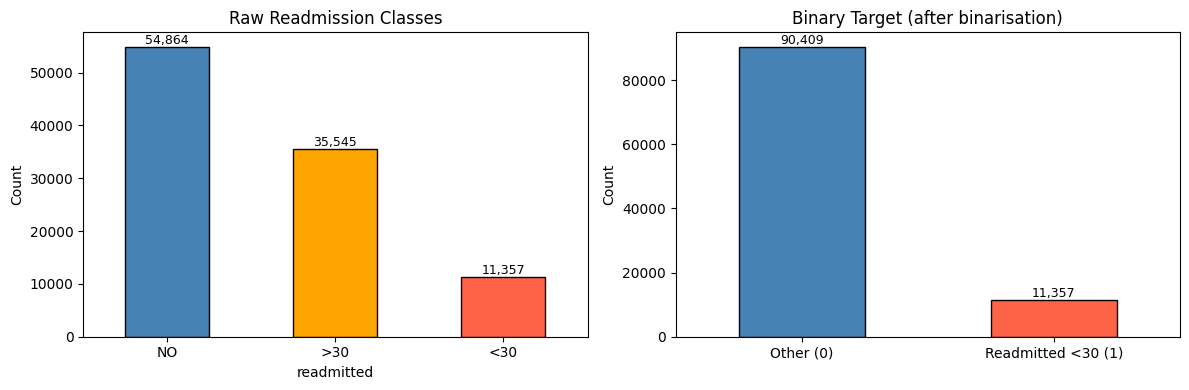

In [18]:
# Data types of the columns
print('----- Column dtype counts -----')
print(f'{df.dtypes.value_counts()}\n')

# Columns with missing values (Represented as '?' in the raw dataset)
missing = (df == '?').sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('----- Columns with missing values -----')
print(missing.to_frame('? count').assign(
    pct=lambda x: (x['? count'] / len(df) * 100).round(1).astype(str) + '%'
))
print()

# Target distribution 
print('----- Target Variable (readmitted) -----')
print(df['readmitted'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df['readmitted'].value_counts()
vc.plot(kind='bar', ax=axes[0], color=['steelblue', 'orange', 'tomato'], edgecolor='black')
axes[0].set_title('Raw Readmission Classes')
axes[0].set_xlabel('readmitted')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

binary_vc = (df['readmitted'] == '<30').value_counts()
binary_vc.index = ['Other (0)', 'Readmitted <30 (1)']
binary_vc.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Binary Target (after binarisation)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. Drop Irrelevant & Unrecoverable Columns

Six columns are removed before any modelling:

| Column | Reason |
|---|---|
| `encounter_id` | Row identifier — no signal |
| `patient_nbr` | Patient identifier — no signal |
| `weight` | ~97% missing — unrecoverable |
| `payer_code` | ~40% missing, not clinically required |
| `medical_specialty` | ~49% missing, very high cardinality |
| `examide`, `citoglipton` | Near-zero variance — almost always `'No'` |

In [4]:
COLS_TO_DROP = [
    'encounter_id', 'patient_nbr',   # identifiers
    'weight',                          # 97% missing
    'payer_code',                      # 40% missing
    'medical_specialty',               # 49% missing, high cardinality
    'examide', 'citoglipton',         # near-zero variance
]

df.drop(columns=COLS_TO_DROP, inplace=True)
print(f'Shape after dropping {len(COLS_TO_DROP)} columns: {df.shape}')

Shape after dropping 7 columns: (101766, 43)


---
## 5. Remove Expired & Hospice Patients

Patients who died or were discharged to hospice **cannot be readmitted**. Keeping them would introduce impossible positive labels and confuse the classifier. We identify them via `discharge_disposition_id`:

| ID | Meaning |
|---|---|
| 11 | Expired |
| 13 | Hospice / medical facility |
| 14 | Hospice / home |
| 19 | Expired at home |
| 20 | Expired in another facility |
| 21 | Expired — place unknown |

In [5]:
EXPIRED_IDS = {11, 13, 14, 19, 20, 21}
before = len(df)
df = df[~df['discharge_disposition_id'].isin(EXPIRED_IDS)].copy()
print(f'Removed {before - len(df):,} expired / hospice records.')
print(f'Shape after removal: {df.shape}')

Removed 2,423 expired / hospice records.
Shape after removal: (99343, 43)


---
## 6. Handle Missing Values

All `?` are now converted to `NaN`. Then:
- **`race`** (~2% missing) → imputed with the column mode (most common race)
- **`gender`** → the handful of `'Unknown/Invalid'` rows are dropped (not imputable)
- **`diag_1/2/3`** → NaN handled inside the ICD-9 mapping function in the next step

In [7]:
# Replace sentinel '?' with NaN
df.replace('?', np.nan, inplace=True)

nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
print('=== NaN counts after ? replacement ===')
print(nan_counts.to_frame('NaN count').assign(
    pct=lambda x: (x['NaN count'] / len(df) * 100).round(1).astype(str) + '%'
))

# Impute race with mode
df['race'].fillna(df['race'].mode()[0], inplace=True)

# Drop the few Unknown/Invalid gender rows
before = len(df)
df = df[df['gender'] != 'Unknown/Invalid'].copy()
print(f'\nDropped {before - len(df)} rows with Unknown/Invalid gender.')

remaining_na = df.isna().sum()
remaining_na = remaining_na[remaining_na > 0]
if len(remaining_na) == 0:
    print('No remaining NaN values outside diag columns (handled in feature engineering).')
else:
    print('\nRemaining NaN:')
    print(remaining_na)

print(f'\nShape: {df.shape}')

=== NaN counts after ? replacement ===
               NaN count    pct
max_glu_serum      94188  94.8%
A1Cresult          82506  83.1%
diag_3              1419   1.4%
diag_2               356   0.4%
diag_1                20   0.0%

Dropped 0 rows with Unknown/Invalid gender.

Remaining NaN:
diag_1              20
diag_2             356
diag_3            1419
max_glu_serum    94188
A1Cresult        82506
dtype: int64

Shape: (99340, 43)


---
## 7. Encode Target Variable

We convert the 3-class `readmitted` column into a **binary target**:

| Original | Binary | Meaning |
|---|---|---|
| `<30` | **1** | Readmitted within 30 days — the rare, high-risk class |
| `NO` | **0** | Not readmitted |
| `>30` | **0** | Readmitted after 30 days (not the clinically urgent case) |

This matches the proposal's focus: detect the ~11% minority class.

In [8]:
df['target'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

vc = df['target'].value_counts()
print('=== Binary Target Distribution ===')
print(f"0 (not readmitted <30): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)")
print(f"1 (readmitted  <30):    {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)")
print(f'\nImbalance ratio: {vc[0]/vc[1]:.1f}:1')

=== Binary Target Distribution ===
0 (not readmitted <30): 88,026  (88.6%)
1 (readmitted  <30):    11,314  (11.4%)

Imbalance ratio: 7.8:1


---
## 8. Feature Engineering

Four transformations to make raw features usable:

1. **`age`** — bracket strings like `[50-60)` → numeric midpoint `55`
2. **`diag_1/2/3`** — ICD-9 codes grouped into 8 clinically meaningful disease categories (Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, Other)
3. **Medication columns (21)** — ordinal encoding: `No=0, Steady=1, Up=2, Down=3`
4. **Binary/ordinal columns** — `change`, `diabetesMed`, `gender`, `A1Cresult`, `max_glu_serum`

In [9]:
# ── 1. Age brackets → numeric midpoint ───────────────────────────────────────
age_map = {
    '[0-10)': 5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age'] = df['age'].map(age_map)
print('age midpoints applied:', sorted(df['age'].unique()))

# ── 2. ICD-9 diagnosis codes → disease category ──────────────────────────────
def icd9_to_category(code):
    """Map an ICD-9 code string to a broad disease category."""
    if pd.isna(code):
        return 'Other'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        num = float(code)
        if 390 <= num <= 459 or num == 785:  return 'Circulatory'
        if 460 <= num <= 519 or num == 786:  return 'Respiratory'
        if 520 <= num <= 579 or num == 787:  return 'Digestive'
        if 250 <= num < 251:                  return 'Diabetes'
        if 800 <= num <= 999:                 return 'Injury'
        if 710 <= num <= 739:                 return 'Musculoskeletal'
        if 580 <= num <= 629 or num == 788:  return 'Genitourinary'
        if 140 <= num <= 239:                 return 'Neoplasms'
        return 'Other'
    except ValueError:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(icd9_to_category)

print('\ndiag_1 category counts:')
print(df['diag_1'].value_counts())

# ── 3. Medication columns → ordinal 0-3 ──────────────────────────────────────
MED_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]
med_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}
df[MED_COLS] = df[MED_COLS].replace(med_map)
print(f'\n{len(MED_COLS)} medication columns encoded (No=0, Steady=1, Up=2, Down=3)')

# ── 4. Binary / ordinal categoricals ─────────────────────────────────────────
df['change']      = (df['change'] == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)
df['gender']      = (df['gender'] == 'Male').astype(int)

glu_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
a1c_map = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
df['max_glu_serum'] = df['max_glu_serum'].map(glu_map)
df['A1Cresult']     = df['A1Cresult'].map(a1c_map)

print('Binary/ordinal encodings complete.')
print(f'\nShape: {df.shape}')

age midpoints applied: [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]

diag_1 category counts:
diag_1
Circulatory        29680
Other              17813
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6851
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Name: count, dtype: int64

21 medication columns encoded (No=0, Steady=1, Up=2, Down=3)
Binary/ordinal encodings complete.

Shape: (99340, 43)


---
## 9. Encode Remaining Categorical Columns

Four string columns remain after feature engineering: `race`, `diag_1`, `diag_2`, `diag_3`.

We use **`LabelEncoder`** (integer codes, not one-hot) because:
- TabDDPM needs integer-coded categoricals to apply multinomial diffusion
- SMOTE and XGBoost also handle label-encoded categoricals without issue

Encoders are saved to disk so the same mapping can be applied to any new/synthetic data.

In [10]:
CAT_COLS = ['race', 'diag_1', 'diag_2', 'diag_3']
label_encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'{col:8s}: {list(le.classes_)} → {list(range(len(le.classes_)))}')

print(f'\nAll columns are now numeric.')
print(df.dtypes.value_counts())
print(f'Shape: {df.shape}')

race    : ['AfricanAmerican', 'Asian', 'Caucasian', 'Hispanic', 'Other'] → [0, 1, 2, 3, 4]
diag_1  : ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory'] → [0, 1, 2, 3, 4, 5, 6, 7, 8]
diag_2  : ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory'] → [0, 1, 2, 3, 4, 5, 6, 7, 8]
diag_3  : ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory'] → [0, 1, 2, 3, 4, 5, 6, 7, 8]

All columns are now numeric.
int64      41
float64     2
Name: count, dtype: int64
Shape: (99340, 43)


---
## 10. Scale Continuous Numeric Features

We apply **`StandardScaler`** (zero mean, unit variance) to the 9 continuous numeric columns. This is required for:
- TabDDPM's Gaussian diffusion process (operates on normalised values)
- Stable gradient flow during neural network training

Note: binary/ordinal columns (0-3 range) are deliberately **not** scaled — their small integer range is meaningful and scaling would distort it.

In [11]:
NUMERIC_COLS = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age'
]

scaler = StandardScaler()
df[NUMERIC_COLS] = scaler.fit_transform(df[NUMERIC_COLS])

print(f'StandardScaler applied to {len(NUMERIC_COLS)} columns:')
print(df[NUMERIC_COLS].describe().T[['mean', 'std', 'min', 'max']].round(3))

StandardScaler applied to 9 columns:
                     mean   std    min    max
time_in_hospital    0.000 1.000 -1.138  3.241
num_lab_procedures -0.000 1.000 -2.137  4.543
num_procedures      0.000 1.000 -0.784  2.740
num_medications    -0.000 1.000 -1.850  8.032
number_outpatient  -0.000 1.000 -0.292 32.906
number_emergency   -0.000 1.000 -0.212 80.834
number_inpatient   -0.000 1.000 -0.501 16.160
number_diagnoses    0.000 1.000 -3.298  4.430
age                 0.000 1.000 -3.810  1.835


---
## 11. Stratified Train-Test Split

Split 80/20 with `stratify=y` to preserve the ~11% minority-class ratio in both sets. The test set is held out entirely and **never used for training or synthetic data generation** — it exists only for final evaluation.

In [12]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows')
print(f'Features: {X_train.shape[1]}')

for name, y_split in [('Train', y_train), ('Test', y_test)]:
    vc = y_split.value_counts().sort_index()
    print(f'\n{name} class distribution:')
    for cls, cnt in vc.items():
        print(f'  Class {cls}: {cnt:,}  ({cnt/len(y_split)*100:.1f}%)')

Train : 79,472 rows  |  Test : 19,868 rows
Features: 42

Train class distribution:
  Class 0: 70,421  (88.6%)
  Class 1: 9,051  (11.4%)

Test class distribution:
  Class 0: 17,605  (88.6%)
  Class 1: 2,263  (11.4%)


---
## 12. Save Processed Data & Preview

Processed splits are written to `data/processed/` so every subsequent stage (baseline, SMOTE, CTGAN, TabDDPM) loads from the same clean starting point without re-running this notebook.

Preprocessing artifacts (scaler, label encoders) are saved to `models/` so synthetic data and new inference data can be preprocessed identically.

In [13]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = '../models'
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Save splits
X_train.to_csv(f'{PROCESSED_DIR}/X_train.csv', index=False)
X_test.to_csv(f'{PROCESSED_DIR}/X_test.csv', index=False)
y_train.to_csv(f'{PROCESSED_DIR}/y_train.csv', index=False)
y_test.to_csv(f'{PROCESSED_DIR}/y_test.csv', index=False)

# Save preprocessing artifacts
joblib.dump(scaler, f'{MODELS_DIR}/scaler.pkl')
joblib.dump(label_encoders, f'{MODELS_DIR}/label_encoders.pkl')

print('Files saved:')
print(f'  {PROCESSED_DIR}/X_train.csv  — {X_train.shape}')
print(f'  {PROCESSED_DIR}/X_test.csv   — {X_test.shape}')
print(f'  {PROCESSED_DIR}/y_train.csv  — {y_train.shape}')
print(f'  {PROCESSED_DIR}/y_test.csv   — {y_test.shape}')
print(f'  {MODELS_DIR}/scaler.pkl')
print(f'  {MODELS_DIR}/label_encoders.pkl')

Files saved:
  ../data/processed/X_train.csv  — (79472, 42)
  ../data/processed/X_test.csv   — (19868, 42)
  ../data/processed/y_train.csv  — (79472,)
  ../data/processed/y_test.csv   — (19868,)
  ../models/scaler.pkl
  ../models/label_encoders.pkl


In [14]:
print('=== Cleaned Training Data — First 10 Rows ===')
display(X_train.head(10))

print(f'\n=== Feature Summary ({len(X_train.columns)} features) ===')
summary = X_train.describe().T[['mean', 'std', 'min', 'max']].round(3)
summary.insert(0, 'dtype', X_train.dtypes)
print(summary.to_string())

=== Cleaned Training Data — First 10 Rows ===


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
4034,2,1,-0.674,1,1,7,-0.128,1.127,-0.784,-0.986,-0.292,-0.212,-0.501,0,0,1,-1.237,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
81888,2,1,-0.047,3,6,1,1.220,1.484,2.740,5.438,-0.292,-0.212,-0.501,0,0,1,0.823,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,1,1
25024,2,1,0.580,1,1,7,-0.465,0.617,0.391,0.126,-0.292,-0.212,-0.501,0,0,0,-0.722,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,1
76238,2,0,-0.047,1,1,7,0.883,1.025,-0.196,0.373,-0.292,-0.212,0.293,7,1,7,0.308,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,1
77845,2,0,1.208,1,3,5,-0.802,1.076,-0.784,-0.244,-0.292,5.120,-0.501,3,0,0,0.823,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
77913,3,1,-0.047,1,3,7,0.209,0.872,0.978,0.744,-0.292,-0.212,-0.501,1,5,7,0.823,NaN,NaN,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3,0,0,0,0,0,1,1
78445,2,1,1.835,3,1,1,-0.465,-2.035,-0.784,-0.739,0.499,-0.212,-0.501,7,2,0,0.823,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
51625,2,0,-0.047,1,1,7,1.894,0.668,0.391,0.744,-0.292,-0.212,-0.501,0,8,0,0.823,NaN,1.000,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1
67462,2,1,-0.047,1,1,7,-1.138,-0.046,-0.784,-0.986,-0.292,1.921,-0.501,8,0,7,0.823,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
13622,2,1,-0.047,6,1,17,-0.128,0.770,-0.784,-1.109,0.499,-0.212,-0.501,7,0,2,-0.207,NaN,NaN,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1



=== Feature Summary (42 features) ===
                            dtype   mean   std    min    max
race                        int64  1.665 0.853  0.000  4.000
gender                      int64  0.462 0.499  0.000  1.000
age                       float64  0.000 1.001 -3.810  1.835
admission_type_id           int64  2.031 1.447  1.000  8.000
discharge_disposition_id    int64  3.517 5.183  1.000 28.000
admission_source_id         int64  5.721 4.063  1.000 25.000
time_in_hospital          float64  0.001 1.001 -1.138  3.241
num_lab_procedures        float64  0.003 1.001 -2.137  4.390
num_procedures            float64 -0.001 0.999 -0.784  2.740
num_medications           float64  0.002 1.002 -1.850  7.785
number_outpatient         float64  0.002 1.001 -0.292 32.906
number_emergency          float64  0.002 1.029 -0.212 80.834
number_inpatient          float64  0.001 1.002 -0.501 16.160
diag_1                      int64  3.524 3.134  0.000  8.000
diag_2                      int64  3.478 3.211